In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def recall_at_k(df, k):
    topk = df[df["rank"] <= k]

    return (
        topk.groupby("variable")["correct"]
        .max()

        .mean()
    )


def precision_at_k(df, k):
    topk = df[df["rank"] <= k]

    return (
        topk.groupby("variable")["correct"]
        .sum()
        .div(k)
        .mean()
    )


def hit_at_k(df, k):
    topk = df[df["rank"] <= k]

    return (
        topk.groupby("variable")["correct"]
        .max()
        .astype(int)
        .mean()
    )


def top1_accuracy(df):
    top1 = df[df["rank"] == 1]

    return top1["correct"].mean()


def mean_reciprocal_rank(df):

    correct_rows = df[df["correct"]]

    if len(correct_rows) == 0:
        return 0

    first_correct_rank = (
        correct_rows.groupby("variable")["rank"]
        .min()
    )

    reciprocal_ranks = 1 / first_correct_rank

    return reciprocal_ranks.mean()


def coverage(df):
    """
    Fraction of variables for which the model
    returned at least one candidate mapping.
    """

    predicted_variables = set(df["variable"].unique())
    total_variables = set(df["schemanode_name"].unique())

    return len(predicted_variables) / len(total_variables)

### Breast cancer data

In [49]:
breast_cancer_df = pd.read_csv('Evaluation/OntoMapping_benchmark/DATA/Breast_cancer.csv')[['schemanode_name', 'optimized_name', 'schemanode_description', 'ontology_id']]
print(f"Number of variables to map: {len(breast_cancer_df)}")
breast_cancer_df.columns

Number of variables to map: 10


Index(['schemanode_name', 'optimized_name', 'schemanode_description',
       'ontology_id'],
      dtype='object')

In [45]:
bc_sm_out = pd.read_csv('results/OntoMapping_benchmark/Clinical_var/Breast_cancer/all_candidates.csv', on_bad_lines='skip')
len(bc_sm_out)

100

In [48]:
bc_sm_out.columns


Index(['variable', 'se_CODE', 'ontology_name', 'confidence', 'CUI'], dtype='object')

### Semantic mapper

In [53]:
!pip install tabulate


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [59]:
def evaluate_semantic_mapper(preds_df, gt_df):
    """
    Computes Recall@1, Recall@5, and Recall@10 for the semantic mapper.
    """

    preds_sorted = preds_df.sort_values(by=['variable', 'confidence'], ascending=[True, False]).copy()

    preds_sorted['rank'] = preds_sorted.groupby('variable').cumcount() + 1


    merged = pd.merge(
        gt_df[['schemanode_name', 'ontology_id']],
        preds_sorted[['variable', 'CUI', 'rank']],
        left_on=['ontology_id'],
        right_on=[ 'CUI'],
        how='left'
    )

    # If 'rank' is NaN, it means the true CUI wasn't in the predicted candidates at all
    # Let's fill those with an impossibly high rank (e.g., 999) for easy filtering
    merged['rank'] = merged['rank'].fillna(999).astype(int)

    # Calculate Total unique variables to evaluate against
    total_variables = gt_df['schemanode_name'].nunique()

    # Calculate successful hits at different thresholds
    hit_at_1 = (merged['rank'] <= 1).sum()
    hit_at_5 = (merged['rank'] <= 5).sum()
    hit_at_10 = (merged['rank'] <= 10).sum()

    # Build the final summary dataframe
    metrics_summary = pd.DataFrame({
        'Metric': ['Recall@1', 'Recall@5', 'Recall@10'],
        'Hits': [hit_at_1, hit_at_5, hit_at_10],
        'Total Variables': [total_variables] * 3,
        'Score (%)': [
            (hit_at_1 / total_variables) * 100,
            (hit_at_5 / total_variables) * 100,
            (hit_at_10 / total_variables) * 100
        ]
    })

    # Format score for readability
    metrics_summary['Score (%)'] = metrics_summary['Score (%)'].round(2)

    return metrics_summary, merged



,schemanode_name,ontology_id,variable,CUI,rank
0,Class,C4034969,NaN,NaN,999
1,age,C4701399,NaN,NaN,999
2,menopause,C0455962,NaN,NaN,999
3,tumor-size,C0475440,NaN,NaN,999
4,inv-nodes,C1299011,NaN,NaN,999
5,node-caps,C5908364,NaN,NaN,999
6,deg-malig,C5546537,NaN,NaN,999
7,breast,C1710547,NaN,NaN,999
8,breast-quad,C5922812,NaN,NaN,999
9,irradiat,C1522449,irradiat,C1522449,8


In [56]:
summary_table, detailed_merge = evaluate_semantic_mapper(bc_sm_out, breast_cancer_df)

print("### EVALUATION SUMMARY ###")
print(summary_table.to_markdown(index=False))

print("\n### DETAILED BREAKDOWN (Per Variable Ground Truth) ###")
print(detailed_merge[['schemanode_name', 'ontology_id', 'rank']].to_markdown(index=False))

### EVALUATION SUMMARY ###
| Metric    |   Hits |   Total Variables |   Score (%) |
|:----------|-------:|------------------:|------------:|
| Recall@1  |      0 |                10 |           0 |
| Recall@5  |      0 |                10 |           0 |
| Recall@10 |      2 |                10 |          20 |

### DETAILED BREAKDOWN (Per Variable Ground Truth) ###
| schemanode_name   | ontology_id   |   rank |
|:------------------|:--------------|-------:|
| Class             | C4034969      |    999 |
| age               | C4701399      |    999 |
| menopause         | C0455962      |    999 |
| tumor-size        | C0475440      |    999 |
| inv-nodes         | C1299011      |    999 |
| node-caps         | C5908364      |    999 |
| deg-malig         | C5546537      |    999 |
| breast            | C1710547      |    999 |
| breast-quad       | C5922812      |    999 |
| irradiat          | C1522449      |      8 |
| irradiat          | C1522449      |      9 |


In [37]:
bc_out = pd.read_csv('results/OntoMapping_benchmark/Clinical_var/Breast_cancer/optimized/mapping_reviews-3.csv', names = ['variable', 'review_status', 'review_explanation', 'rank', 'CUI',
       'CUI_label', 'representative_names', 'confidence', 'reasoning'])

bc_out

,variable,review_status,review_explanation,rank,CUI,CUI_label,representative_names,confidence,reasoning
0,Binary class for breast cancer recurrence,INVALID,The RAG mapping selected the CUI for personal ...,1,C0006142,Malignant neoplasm of breast,Malignant neoplasm of breast | Breast carcinom...,0.56,This CUI represents the core malignant breast ...
1,Binary class for breast cancer recurrence,INVALID,The RAG mapping selected the CUI for personal ...,2,C0260421,Personal history of malignant neoplasm of breast,Personal history of malignant neoplasm of brea...,0.54,"Indicates a prior breast cancer diagnosis, whi..."
2,Binary class for breast cancer recurrence,INVALID,The RAG mapping selected the CUI for personal ...,3,C0154084,Carcinoma in situ of breast,Carcinoma in situ of breast | Non-invasive bre...,0.58,Denotes an early breast cancer stage; includes...
3,Binary class for breast cancer recurrence,INVALID,The RAG mapping selected the CUI for personal ...,4,C0348409,Other carcinoma in situ of breast,Other carcinoma in situ of breast | Other non-...,0.58,Similar to the previous concept but broader fo...
4,Binary class for breast cancer recurrence,INVALID,The RAG mapping selected the CUI for personal ...,5,C1261325,Family history of malignant neoplasm of breast,Family history of malignant neoplasm of breast...,0.58,Relates to hereditary risk; not directly relev...
5,Binary class for breast cancer recurrence afte...,Needs_Review,The RAG mapping selected a personal history co...,1,C0260421,Personal history of malignant neoplasm of breast,Personal history of malignant neoplasm of brea...,0.51,This concept captures a patient having previou...
6,Binary class for breast cancer recurrence afte...,Needs_Review,The RAG mapping selected a personal history co...,2,C0154084,Carcinoma in situ of breast,Carcinoma in situ of breast | Carcinoma in sit...,0.51,"An early stage breast cancer concept, related ..."
7,Binary class for breast cancer recurrence afte...,Needs_Review,The RAG mapping selected a personal history co...,3,C1261325,Family history of malignant neoplasm of breast,Family history of malignant neoplasm of breast,0.60,"Reflects familial breast cancer risk, indirect..."
8,Binary class for breast cancer recurrence afte...,Needs_Review,The RAG mapping selected a personal history co...,4,C0348409,Other carcinoma in situ of breast,Other carcinoma in situ of breast,0.59,"Another early breast cancer type, less directl..."
9,Binary class for breast cancer recurrence afte...,Needs_Review,The RAG mapping selected a personal history co...,5,C0260507,Family history of malignant neoplasm of trache...,Family history of malignant neoplasm of trache...,0.51,Only family history concept unrelated to breas...


In [17]:
bc_df_merged = bc_out.merge(
    breast_cancer_df,
    left_on="variable",
    right_on="optimized_name",
    how="inner"
)

In [18]:
bc_df_merged['correct'] = (
    bc_df_merged['CUI'].astype(str).str.strip().str.upper()
    ==
    bc_df_merged["ontology_id"].astype(str).str.strip().str.upper()
)
bc_df_merged


,variable,review_status,review_explanation,rank,CUI,CUI_label,representative_names,confidence,reasoning,schemanode_name,optimized_name,schemanode_description,ontology_id,correct
0,Binary class for breast cancer recurrence afte...,Needs_Review,The RAG mapping selected a personal history co...,1,C0260421,Personal history of malignant neoplasm of breast,Personal history of malignant neoplasm of brea...,0.51,This concept captures a patient having previou...,Class,Binary class for breast cancer recurrence afte...,binary classification label that indicates if ...,C4034969,False
1,Binary class for breast cancer recurrence afte...,Needs_Review,The RAG mapping selected a personal history co...,2,C0154084,Carcinoma in situ of breast,Carcinoma in situ of breast | Carcinoma in sit...,0.51,"An early stage breast cancer concept, related ...",Class,Binary class for breast cancer recurrence afte...,binary classification label that indicates if ...,C4034969,False
2,Binary class for breast cancer recurrence afte...,Needs_Review,The RAG mapping selected a personal history co...,3,C1261325,Family history of malignant neoplasm of breast,Family history of malignant neoplasm of breast,0.60,"Reflects familial breast cancer risk, indirect...",Class,Binary class for breast cancer recurrence afte...,binary classification label that indicates if ...,C4034969,False
3,Binary class for breast cancer recurrence afte...,Needs_Review,The RAG mapping selected a personal history co...,4,C0348409,Other carcinoma in situ of breast,Other carcinoma in situ of breast,0.59,"Another early breast cancer type, less directl...",Class,Binary class for breast cancer recurrence afte...,binary classification label that indicates if ...,C4034969,False
4,Binary class for breast cancer recurrence afte...,Needs_Review,The RAG mapping selected a personal history co...,5,C0260507,Family history of malignant neoplasm of trache...,Family history of malignant neoplasm of trache...,0.51,Only family history concept unrelated to breas...,Class,Binary class for breast cancer recurrence afte...,binary classification label that indicates if ...,C4034969,False
5,Patient age (categorical),Needs_Review,The RAG mapping to Senility (C0231337) does no...,1,C0231337,Senility,Senility,0.56,"This CUI represents senility, a state of old a...",age,Patient age (categorical),Groups of reported patient age in year at visi...,C4701399,False
6,menopause state of the patient (categorical),VALID,CUI C0495121 correctly represents the concept ...,1,C0495121,Menopausal and female climacteric states,Menopausal and female climacteric states,0.76,"This CUI directly denotes menopausal status, e...",menopause,menopause state of the patient (categorical),menopausal state of the patient. Can be either...,C0455962,False
7,menopause state of the patient (categorical),VALID,CUI C0495121 correctly represents the concept ...,2,C0495122,"Menopausal and perimenopausal disorder, unspec...","Menopausal and perimenopausal disorder, unspec...",0.70,"While this CUI captures perimenopausal states,...",menopause,menopause state of the patient (categorical),menopausal state of the patient. Can be either...,C0455962,False
8,menopause state of the patient (categorical),VALID,CUI C0495121 correctly represents the concept ...,3,C0495120,Menopausal and other perimenopausal disorders,Menopausal and other perimenopausal disorders,0.66,This CUI is specific to perimenopausal disorde...,menopause,menopause state of the patient (categorical),menopausal state of the patient. Can be either...,C0455962,False
9,menopause state of the patient (categorical),VALID,CUI C0495121 correctly represents the concept ...,4,C0156410,States associated with artificial menopause,States associated with artificial menopause,0.73,"This concept relates to induced menopause, whi...",menopause,menopause state of the patient (categorical),menopausal state of the patient. Can be either...,C0455962,False


In [19]:
bc_df_merged.columns


Index(['variable', 'review_status', 'review_explanation', 'rank', 'CUI',
       'CUI_label', 'representative_names', 'confidence', 'reasoning',
       'schemanode_name', 'optimized_name', 'schemanode_description',
       'ontology_id', 'correct'],
      dtype='object')

In [20]:
df_sorted = bc_df_merged.sort_values(["variable", "rank"])

# Group candidates per variable
df_sorted["candidate_text"] = (
    df_sorted["rank"].astype(str)
    + ". "
    + df_sorted["CUI_label"]
    + " ("
    + df_sorted["CUI"]
    + ") "
    + df_sorted["correct"].map({True: "✓", False: ""})
)

summary_df = (
    df_sorted
    .groupby("variable", as_index=False)
    .agg({
        "schemanode_description": "first",

        "candidate_text": lambda x: "\n".join(x)
    })
    .rename(columns={
        "schemanode_description": "variable_description",
        "candidate_text": "candidate_mappings"})
)


In [21]:
summary_df


,variable,variable_description,candidate_mappings
0,Binary class for breast cancer recurrence afte...,binary classification label that indicates if ...,1. Personal history of malignant neoplasm of b...
1,Involved lymph nodes (categorical),Number of involved lymph nodes. Given in the f...,1. Lymph nodes (C0154054) \n2. Enlarged lymph ...
2,Patient age (categorical),Groups of reported patient age in year at visi...,1. Senility (C0231337)
3,breast cancer location (right or left),Side of the body where the breast carcinoma is...,1. Malignant neoplasm of breast (C0006142) \n2...
4,histological degree of the malignancy score,histological degree of the malignancy score,1. Abnormal findings in specimens from other o...
5,menopause state of the patient (categorical),menopausal state of the patient. Can be either...,1. Menopausal and female climacteric states (C...
6,size of the tumor (categorical),Size of the tumor. It is given in the followin...,1. Malignant neoplasms (C0006826) \n2. Neoplas...


In [22]:
summary_df.to_csv('results/OntoMapping_benchmark/Clinical_var/Breast_cancer/optimized/output-3.csv')

In [23]:
# =========================================================
# COMPUTE METRICS
# =========================================================

metrics = {}

for k in [1, 3, 5, 10]:

    metrics[f"Recall@{k}"] = recall_at_k(bc_df_merged, k)
    metrics[f"Precision@{k}"] = precision_at_k(bc_df_merged, k)
    metrics[f"Hit@{k}"] = hit_at_k(bc_df_merged, k)

metrics["Top1_Accuracy"] = top1_accuracy(bc_df_merged)
metrics["MRR"] = mean_reciprocal_rank(bc_df_merged)
metrics["Coverage"] = coverage(bc_df_merged)

metrics_df = pd.DataFrame.from_dict(
    metrics,
    orient="index",
    columns=["score"]
)

print(metrics_df.round(4))



               score
Recall@1         0.0
Precision@1      0.0
Hit@1            0.0
Recall@3         0.0
Precision@3      0.0
Hit@3            0.0
Recall@5         0.0
Precision@5      0.0
Hit@5            0.0
Recall@10        0.0
Precision@10     0.0
Hit@10           0.0
Top1_Accuracy    0.0
MRR              0.0
Coverage         1.0


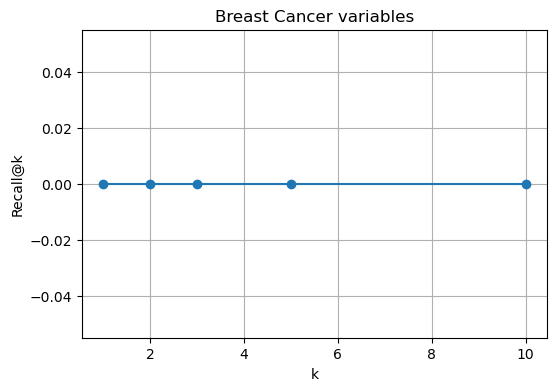

In [24]:
# =========================================================
# RECALL@K CURVE
# =========================================================

ks = [1, 2, 3, 5, 10]

recalls = [recall_at_k(bc_df_merged, k) for k in ks]

plt.figure(figsize=(6,4))

plt.plot(ks, recalls, marker="o")

plt.xlabel("k")
plt.ylabel("Recall@k")
plt.title("Breast Cancer variables")

plt.grid(True)

plt.show()

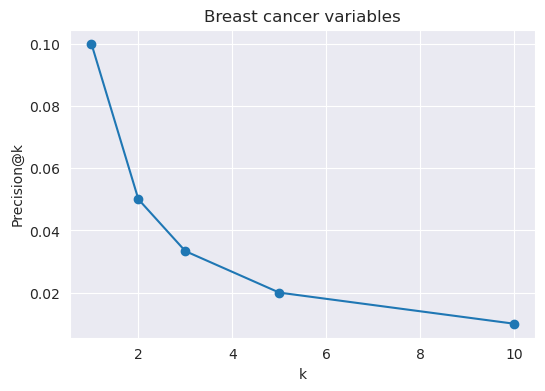

In [12]:
# =========================================================
# PRECISION@K CURVE
# =========================================================

ks = [1, 2, 3, 5, 10]

recalls = [precision_at_k(bc_df_merged, k) for k in ks]

plt.figure(figsize=(6,4))

plt.plot(ks, recalls, marker="o")

plt.xlabel("k")
plt.ylabel("Precision@k")

plt.title("Breast cancer variables")

plt.grid(True)

plt.show()

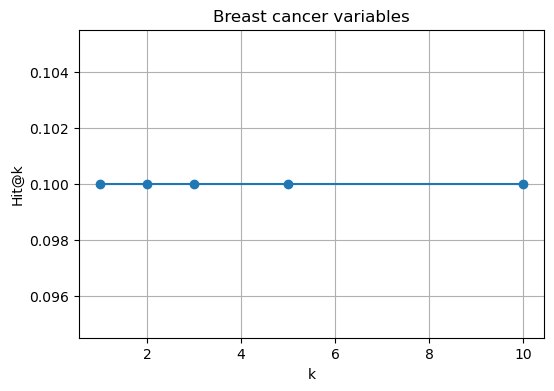

In [52]:
# =========================================================
# HIT@K CURVE
# =========================================================

ks = [1, 2, 3, 5, 10]

recalls = [hit_at_k(bc_df_merged, k) for k in ks]

plt.figure(figsize=(6,4))

plt.plot(ks, recalls, marker="o")

plt.xlabel("k")
plt.ylabel("Hit@k")

plt.title("Breast cancer variables")

plt.grid(True)

plt.show()

In [25]:
# ==============================================================================
# RANK DISTRIBUTION OF CORRECT MAPPING
# ==============================================================================

correct_ranks = (
    bc_df_merged[bc_df_merged["correct"]]
    .groupby("variable")["rank"]
    .min()
)

print(correct_ranks.describe())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: rank, dtype: float64


In [14]:
failures = (
    bc_df_merged.groupby("variable")["correct"]
    .max()
)

missed_variables = failures[failures == False].index

failure_df = bc_df_merged[
    bc_df_merged["schemanode_name"].isin(missed_variables)
]

print(failure_df.head())

    variable review_status                                 review_explanation  \
0      Class       INVALID  The RAG pick C0456387 (Class) is too generic f...   
1      Class       INVALID  The RAG pick C0456387 (Class) is too generic f...   
2      Class       INVALID  The RAG pick C0456387 (Class) is too generic f...   
3        age         VALID  CUI C0001779 accurately represents the concept...   
4  menopause       INVALID  The RAG primary CUI C0567312 represents menopa...   

   rank       CUI       CUI_label  \
0     1  C0008902  Classification   
1     2  C0456387           Class   
2     3  C0445604        Subclass   
3     1  C0001779             Age   
4     1  C0025320       Menopause   

                                representative_names  confidence  \
0  Classification | Classified | Classification (...        0.81   
1                Class | Classes | Class (attribute)        1.00   
2                    Subclass | Subclass (attribute)        0.85   
3     Age | Age (o

### MicrobAIome data

In [5]:
microbaiome_df = pd.read_csv('Evaluation/OntoMapping_benchmark/DATA/MicrobAIome.csv')[['schemanode_name', 'schemanode_description', 'ontology_id']]
print(f"Number of variables to map: {len(microbaiome_df)}")
microbaiome_df.head()

Number of variables to map: 36


,schemanode_name,schemanode_description,ontology_id
0,Sex at birth,Sex at birth,C5968453
1,BMI,Body mass index,C1305855
2,Diarrhea,Patient has Diarrhea,C0011991
3,Constipation,Patient has Constipation,C0009806
4,Rectal hemorrhage,Patient has rectal hemorrhage,C0267596


In [17]:
mb_candidates= pd.read_csv('results/OntoMapping_benchmark/Clinical_var/MicrobAIome/all_candidates-2.csv')
mb_candidates.head(10)

,variable,se_CODE,ontology_name,confidence,CUI
0,Sex at birth,281053000,Biological sex at birth,0.96,C0419383
1,Sex at birth,281053000,Sex assigned at birth,0.92,C0419383
2,Sex at birth,268476009,Sex of baby,0.90,C0542460
3,Sex at birth,147068009,Sex of baby,0.90,C0542460
4,Sex at birth,169837005,Sex of baby,0.90,C0542460
5,Sex at birth,147078007,Sex of baby NOS,0.89,C0542460
6,Sex at birth,147078007,Sex of baby NOS,0.89,C0542460
7,Sex at birth,169847008,Sex of baby NOS,0.89,C0542460
8,Sex at birth,268476009,Sex of baby (observable entity),0.89,C0542460
9,Sex at birth,147078007,Sex of baby NOS (observable entity),0.89,C0542460


In [6]:
mb_out = pd.read_csv('results/OntoMapping_benchmark/Clinical_var/MicrobAIome/mapping_reviews-3.csv')

mb_out.columns


Index(['variable', 'review_status', 'review_explanation', 'rank', 'CUI',
       'CUI_label', 'representative_names', 'confidence', 'reasoning'],
      dtype='object')

In [24]:
mb_out.columns

Index(['variable', 'review_status', 'review_explanation', 'rank', 'CUI',
       'CUI_label', 'representative_names', 'confidence', 'reasoning'],
      dtype='object')

In [6]:
mb_df_merged = mb_out.merge(
    microbaiome_df,
    left_on="variable",
    right_on="schemanode_name",
    how="inner"
)

In [7]:
mb_df_merged['correct'] = (
    mb_df_merged['CUI'].astype(str).str.strip().str.upper()
    ==
    mb_df_merged["ontology_id"].astype(str).str.strip().str.upper()
)
mb_df_merged.head()

,variable,review_status,review_explanation,rank,CUI,CUI_label,representative_names,confidence,reasoning,schemanode_name,schemanode_description,ontology_id,correct
0,Sex at birth,VALID,CUI C0419383 represents the clinical concept o...,1,C0419383,Biological sex at birth,Biological sex at birth | Sex assigned at birth,0.96,This CUI directly denotes the sex assigned at ...,Sex at birth,Sex at birth,C5968453,False
1,Sex at birth,VALID,CUI C0419383 represents the clinical concept o...,2,C0542460,Sex of baby,Sex of baby | Sex of baby NOS | Sex of baby (o...,0.90,This CUI describes the baby's sex in a broader...,Sex at birth,Sex at birth,C5968453,False
2,BMI,VALID,The RAG mapping correctly identifies CUI C1305...,1,C1305855,BMI - Body mass index,BMI - Body mass index | Body mass index | Body...,0.92,This CUI directly represents the clinical meas...,BMI,Body mass index,C1305855,True
3,Diarrhea,VALID,"The RAG mapping correctly identifies C0011991,...",1,C0011991,Diarrhea,Diarrhea | Diarrhea (finding) | Diarrhea symptom,1.00,C0011991 is the precise concept for diarrhea a...,Diarrhea,Patient has Diarrhea,C0011991,True
4,Diarrhea,VALID,"The RAG mapping correctly identifies C0011991,...",2,C1290807,Diarrhea disorder,Diarrhea disorder,0.98,C1290807 refers to a disorder level of diarrhe...,Diarrhea,Patient has Diarrhea,C0011991,False


In [8]:
# =========================================================
# COMPUTE METRICS
# =========================================================

metrics = {}

for k in [1, 3, 5, 10]:

    metrics[f"Recall@{k}"] = recall_at_k(mb_df_merged, k)
    metrics[f"Precision@{k}"] = precision_at_k(mb_df_merged, k)
    metrics[f"Hit@{k}"] = hit_at_k(mb_df_merged, k)

metrics["Top1_Accuracy"] = top1_accuracy(mb_df_merged)
metrics["MRR"] = mean_reciprocal_rank(mb_df_merged)

metrics_df = pd.DataFrame.from_dict(
    metrics,
    orient="index",
    columns=["score"]
)

print(metrics_df.round(4))


                score
Recall@1       0.5000
Precision@1    0.5000
Hit@1          0.5000
Recall@3       0.6471
Precision@3    0.2157
Hit@3          0.6471
Recall@5       0.6471
Precision@5    0.1294
Hit@5          0.6471
Recall@10      0.6471
Precision@10   0.0647
Hit@10         0.6471
Top1_Accuracy  0.5000
MRR            0.8712


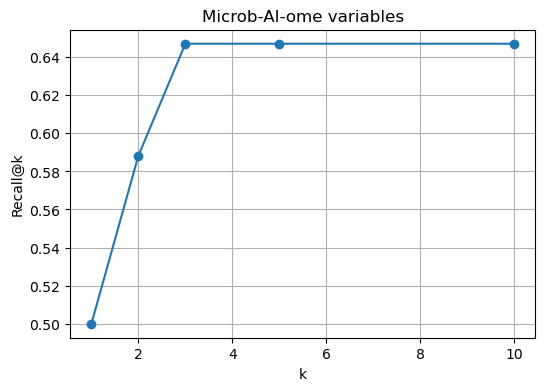

In [9]:
# =========================================================
# RECALL@K CURVE
# =========================================================

ks = [1, 2, 3, 5, 10]

recalls = [recall_at_k(mb_df_merged, k) for k in ks]

plt.figure(figsize=(6,4))

plt.plot(ks, recalls, marker="o")

plt.xlabel("k")
plt.ylabel("Recall@k")
plt.title("Microb-AI-ome variables")

plt.grid(True)

plt.show()

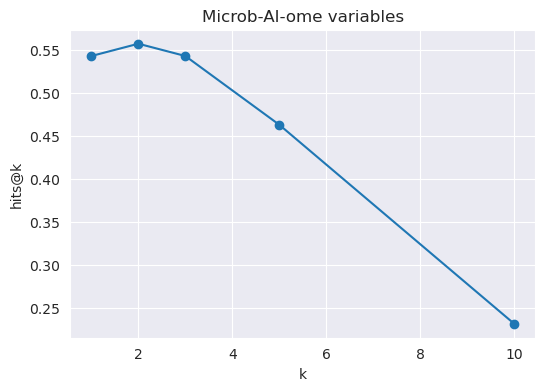

In [37]:
# =========================================================
# PRECISION@K CURVE
# =========================================================

ks = [1, 2, 3, 5, 10]

recalls = [precision_at_k(mb_df_merged, k) for k in ks]

plt.figure(figsize=(6,4))

plt.plot(ks, recalls, marker="o")

plt.xlabel("k")
plt.ylabel("hits@k")
plt.title("Microb-AI-ome variables")

plt.grid(True)

plt.show()

In [11]:
df_sorted = mb_df_merged.sort_values(["variable", "rank"])

# Group candidates per variable
df_sorted["candidate_text"] = (
    df_sorted["rank"].astype(str)
    + ". "
    + df_sorted["CUI_label"]
    + " ("
    + df_sorted["CUI"]
    + ") "
    + df_sorted["correct"].map({True: "✓", False: ""})
)

summary_df = (
    df_sorted
    .groupby("variable", as_index=False)
    .agg({
        "schemanode_description": "first",

        "candidate_text": lambda x: "\n".join(x)
    })
    .rename(columns={
        "schemanode_description": "variable_description",
        "candidate_text": "candidate_mappings"})
)


In [12]:
summary_df.head()

,variable,variable_description,candidate_mappings
0,Antibiotics,Patient has used antibiotics within the last 3...,1. Antibiotic therapy (C0338237) \n2. Antibact...
1,Any disease,The patient suffers from any unspecified disease,1. Unspecified conditions (disorder) (C0438984...
2,Aspirin Dosage,Amount of Aspirin the patient is taking,1. Aspirin given (C2315089) \n2. Aspirin measu...
3,BMI,Body mass index,1. BMI - Body mass index (C1305855) ✓
4,CRC,Patient has colorectal cancer,1. Colorectal cancer (C5848476) \n2. Colorecta...


In [13]:
summary_df.to_csv('results/OntoMapping_benchmark/Clinical_var/MicrobAIome/output-3.csv')


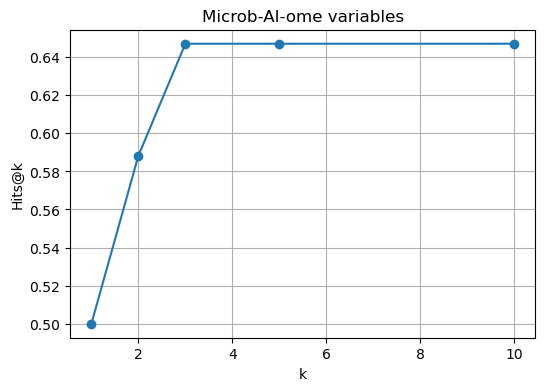

In [10]:
# =========================================================
# HIT@K CURVE
# =========================================================

ks = [1, 2, 3, 5, 10]

recalls = [hit_at_k(mb_df_merged, k) for k in ks]

plt.figure(figsize=(6,4))

plt.plot(ks, recalls, marker="o")

plt.xlabel("k")
plt.ylabel("Hits@k")

plt.title("Microb-AI-ome variables")

plt.grid(True)

plt.show()

### Bio-NNEL DATA

In [16]:
from datasets import load_dataset

huggingface_path = "andorei/BioNNE-L"
dev_data = load_dataset(huggingface_path, "English", split="dev")
dev_df = dev_data.to_pandas().iloc[:100, :]

/home/bbf1146/miniconda3/envs/lu_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
# count numbers of duplicate variables
duplicate_array = (dev_df['text'].value_counts() > 1).values
len(dev_df['text'].value_counts()[duplicate_array])

18

In [3]:
import os
os.getcwd()

'/home/bbf1146/Schema_DH'

In [12]:
bn_out = pd.read_csv('results/OntoMapping_benchmark/Clinical_var/Bio-NELL/mapping_reviews-3.csv') #,                       names =                          # ['variable', 'review_status', 'review_explanation', 'rank', 'CUI',
                        #      'CUI_label', 'representative_names', 'confidence', 'reasoning'])

bn_out

,variable,review_status,review_explanation,rank,CUI,CUI_label,representative_names,confidence,reasoning
0,depression,INVALID,"The RAG selected C1999266, a generic ""Depressi...",1,C0011570,Depression (disorder),Depression | Depression (disorder) | Depressio...,1.00,This CUI represents depression as a clinical d...
1,depression,INVALID,"The RAG selected C1999266, a generic ""Depressi...",2,C0011581,Depression (finding),Depression | Depression (finding) | Depression...,1.00,This CUI captures depression as a clinical fin...
2,depression,INVALID,"The RAG selected C1999266, a generic ""Depressi...",3,C0086132,depression symptom,depression symptom | depression symptoms | sym...,0.98,"This CUI represents depression as a symptom, w..."
3,depression,INVALID,"The RAG selected C1999266, a generic ""Depressi...",4,C1579931,depression,depression | depression (symptom) | depression...,1.00,This CUI denotes depression but is less specif...
4,depression,INVALID,"The RAG selected C1999266, a generic ""Depressi...",5,C1999266,Depression,Depression,1.00,This is the generic depression concept chosen ...
...,...,...,...,...,...,...,...,...,...
594,cardiac,VALID,C0018787 correctly represents the heart as a b...,1,C0018787,Cardiac,Cardiac | Heart | Cardiac structure,1.00,This CUI encompasses the heart as an anatomica...
595,cardiac,VALID,C0018787 correctly represents the heart as a b...,2,C1281570,Heart,Heart,0.92,A specific heart concept that still maps direc...
596,cardiac,VALID,C0018787 correctly represents the heart as a b...,3,C0153957,Heart,Heart,0.92,Another heart concept that provides a relevant...
597,cardiac,VALID,C0018787 correctly represents the heart as a b...,4,C0153500,Heart,Heart,0.92,Same heart concept; included to reflect distin...


In [14]:
bn_out.groupby("variable")['CUI'].apply(list).reset_index(name='CUI_list')


,variable,CUI_list
0,CAD,"[C1956346, C4534432, C2317524, C1504769, C1842..."
1,CHD,"[C0010068, C1956346, C0010054, C3542407, C0620..."
2,Cardiovascular,"[C0007226, C1269562, C3540036, C3540015, C0425..."
3,Cardiovascular diseases,"[C0007222, C1971640]"
4,Frontal,"[C3697576, C0921044, C1280991, C0016733, C0162..."
...,...,...
57,right-sided pneumonia,"[C0585106, C0585105, C0578577]"
58,sulfur,"[C2348286, C0038774]"
59,sulfur dioxide,"[C0038777, C0161714, C0038782, C0917965, C0075..."
60,transfusion-related pulmonary edema,"[C0398667, C2921022, C0948343, C1739101, C3267..."


In [34]:
bn_df_merged = bn_out.merge(
    dev_df,
    left_on="variable",
    right_on="text",
    how="inner"
)

bn_df_merged.head()
len(bn_df_merged)


1718

In [35]:
1718/5

343.6

In [9]:
bn_df_merged['correct'] = (
    bn_df_merged['CUI'].astype(str).str.strip().str.upper()
    ==
    bn_df_merged["UMLS_CUI"].astype(str).str.strip().str.upper()
)
bn_df_merged.head()

,variable,review_status,review_explanation,rank,CUI,CUI_label,representative_names,confidence,reasoning,document_id,text,entity_type,spans,UMLS_CUI,correct
0,depression,INVALID,The RAG selected C1999266 (Major depressive di...,1,C0011570,Depression,Depression | Depression NOS | Depression (find...,1.0,Depressive disorder is a broad diagnostic cate...,25726786_en,depression,DISO,686-696,C0011570,True
1,depression,INVALID,The RAG selected C1999266 (Major depressive di...,2,C0011581,Depression,Depression | depression nos | depression (diag...,1.0,Depression is a general term including diagnos...,25726786_en,depression,DISO,686-696,C0011570,False
2,depression,INVALID,The RAG selected C1999266 (Major depressive di...,3,C1999266,Depression,Depression,1.0,Major depressive disorder is a specific subtyp...,25726786_en,depression,DISO,686-696,C0011570,False
3,depression,INVALID,The RAG selected C1999266 (Major depressive di...,4,C0812393,depression,depression,1.0,This CUI likely represents a specific diagnost...,25726786_en,depression,DISO,686-696,C0011570,False
4,depression,INVALID,The RAG selected C1999266 (Major depressive di...,5,C1579931,depression,depression,1.0,This concept may refer to a symptom rather tha...,25726786_en,depression,DISO,686-696,C0011570,False


In [ ]:
,

In [20]:
bn_df_merged[['variable', 'CUI', 'CUI_label', 'UMLS_CUI', 'correct']][bn_df_merged['variable'] == 'CAD']

,variable,CUI,CUI_label,UMLS_CUI,correct
39,CAD,C1956346,CAD (coronary artery disease),C1956346,True
40,CAD,C1956346,CAD (coronary artery disease),C1956346,True
41,CAD,C1956346,CAD (coronary artery disease),C1956346,True
42,CAD,C1956346,CAD (coronary artery disease),C1956346,True
43,CAD,C1956346,CAD (coronary artery disease),C1956346,True
...,...,...,...,...,...
214,CAD,C1609419,R-CAD,C1956346,False
215,CAD,C1609419,R-CAD,C1956346,False
216,CAD,C1609419,R-CAD,C1956346,False
217,CAD,C1609419,R-CAD,C1956346,False


In [19]:
k = 3
topk = bn_df_merged[bn_df_merged["rank"] <= k]


topk.groupby("variable")["correct"].sum()#.div(k).mean()





variable
CAD                                    25
CHD                                     4
Cardiovascular                          0
Cardiovascular diseases                 1
Frontal                                 0
                                       ..
right-sided pneumonia                   0
sulfur                                  1
sulfur dioxide                          1
transfusion-related pulmonary edema     1
zinc                                    2
Name: correct, Length: 62, dtype: int64

In [ ]:
# =========================================================
# COMPUTE METRICS
# =========================================================

metrics = {}

for k in [1, 3, 5, 10]:

    metrics[f"Recall@{k}"] = recall_at_k(bn_df_merged, k)
    metrics[f"Precision@{k}"] = precision_at_k(bn_df_merged, k)
    metrics[f"Hit@{k}"] = hit_at_k(bn_df_merged, k)

metrics["Top1_Accuracy"] = top1_accuracy(bn_df_merged)
metrics["MRR"] = mean_reciprocal_rank(bn_df_merged)

metrics_df = pd.DataFrame.from_dict(
    metrics,
    orient="index",
    columns=["score"]
)

print(metrics_df.round(4))


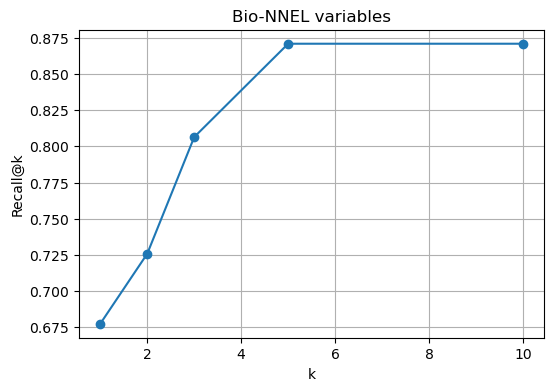

In [36]:
# =========================================================
# RECALL@K CURVE
# =========================================================

ks = [1, 2, 3, 5, 10]

recalls = [recall_at_k(bn_df_merged, k) for k in ks]

plt.figure(figsize=(6,4))

plt.plot(ks, recalls, marker="o")

plt.xlabel("k")
plt.ylabel("Recall@k")
plt.title("Bio-NNEL variables")

plt.grid(True)

plt.show()

In [37]:
df_sorted = bn_df_merged.sort_values(["variable", "rank"])

# Group candidates per variable
df_sorted["candidate_text"] = (
    df_sorted["rank"].astype(str)
    + ". "
    + df_sorted["CUI_label"]
    + " ("
    + df_sorted["CUI"]
    + ") "
    + df_sorted["correct"].map({True: "✓", False: ""})
)

summary_df = (
    df_sorted
    .groupby("variable", as_index=False)
    .agg({
        "entity_type": "first",

        "candidate_text": lambda x: "\n".join(x)
    })
    .rename(columns={
        "schemanode_description": "variable_description",
        "candidate_text": "candidate_mappings"})
)


In [38]:
summary_df.head()

,variable,entity_type,candidate_mappings
0,CAD,DISO,1. CAD (coronary artery disease) (C1956346) ✓\...
1,CHD,DISO,1. Coronary heart disease (C0010068) ✓\n1. Cor...
2,Cardiovascular,ANATOMY,1. Cardiovascular structure (body structure) (...
3,Cardiovascular diseases,DISO,1. Cardiovascular Diseases (C0007222) ✓
4,Frontal,ANATOMY,1. Frontal region structure (body structure) (...


In [39]:
summary_df.to_csv('results/OntoMapping_benchmark/Clinical_var/Bio-NELL/output-3.csv')
